In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
# Đường dẫn dữ liệu
data_path = '/content/drive/MyDrive/Gym/data/GymFill_0.2'
model_paths = [
    '/content/drive/MyDrive/Gym/Model/lstm_model_bs4_sl30_ol25.keras',
    '/content/drive/MyDrive/Gym/Model/lstm_model_bs4_sl15_ol10_2.keras',
]

output_file = '/content/drive/MyDrive/Gym/Model/test_results_2.csv'

In [4]:
# Danh sách độ dài chuỗi cần kiểm tra
# sequence_lengths = [30, 45, 50]
# overlap = 0
mask_value = 0

In [5]:
def load_data_with_fixed_length(base_path, sequence_length, overlap = 0):
    X, y = [], []
    actions = os.listdir(base_path)
    for label, action in enumerate(actions):
        action_path = os.path.join(base_path, action)
        if os.path.isdir(action_path):
            for file in os.listdir(action_path):
                file_path = os.path.join(action_path, file)
                if file.endswith('.csv'):
                    df = pd.read_csv(file_path).iloc[:, 1:]
                    total_rows = df.shape[0]
                    for start_idx in range(0, total_rows, sequence_length - overlap):
                        end_idx = start_idx + sequence_length
                        if end_idx > total_rows:
                            break
                        segment = df.iloc[start_idx:end_idx].values
                        X.append(segment)
                        y.append(label)
    return np.array(X), np.array(y)

Testing model: /content/drive/MyDrive/Gym/Model/lstm_model_bs4_sl30_ol25.keras with sequence length 30
Full Data Loss: 0.13107416033744812, Full Data Accuracy: 0.9618782997131348
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


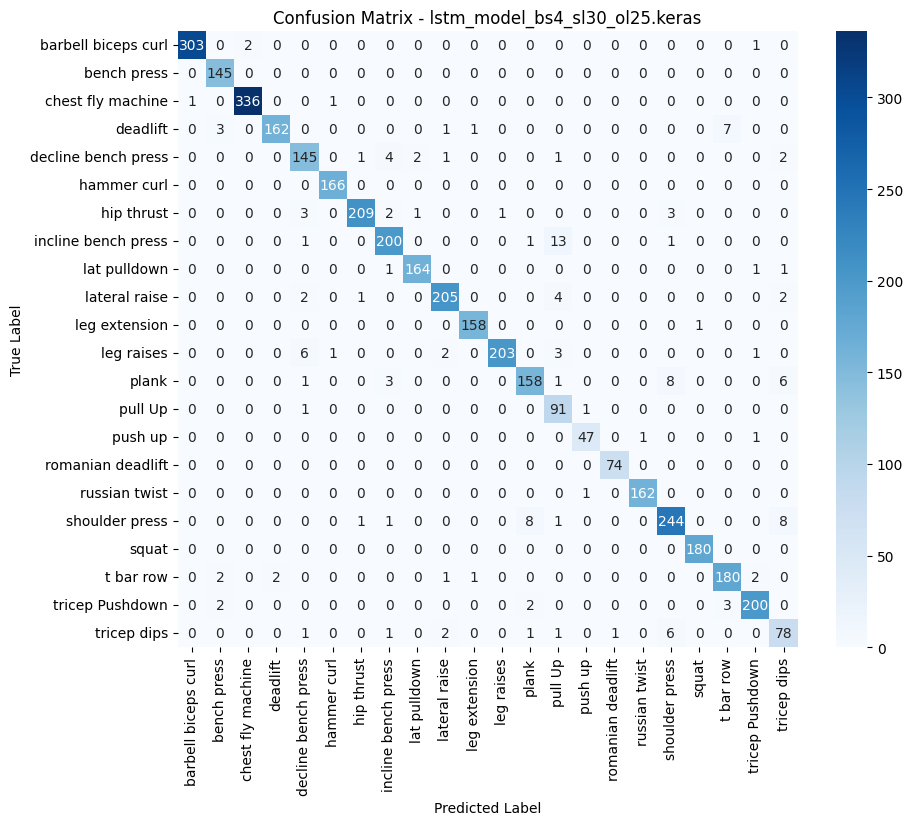

                     precision    recall  f1-score      support
barbell biceps curl   0.996711  0.990196  0.993443   306.000000
bench press           0.953947  1.000000  0.976431   145.000000
chest fly machine     0.994083  0.994083  0.994083   338.000000
deadlift              0.987805  0.931034  0.958580   174.000000
decline bench press   0.906250  0.929487  0.917722   156.000000
hammer curl           0.988095  1.000000  0.994012   166.000000
hip thrust            0.985849  0.954338  0.969838   219.000000
incline bench press   0.943396  0.925926  0.934579   216.000000
lat pulldown          0.982036  0.982036  0.982036   167.000000
lateral raise         0.966981  0.957944  0.962441   214.000000
leg extension         0.987500  0.993711  0.990596   159.000000
leg raises            0.995098  0.939815  0.966667   216.000000
plank                 0.929412  0.892655  0.910663   177.000000
pull Up               0.791304  0.978495  0.875000    93.000000
push up               0.959184  0.959184

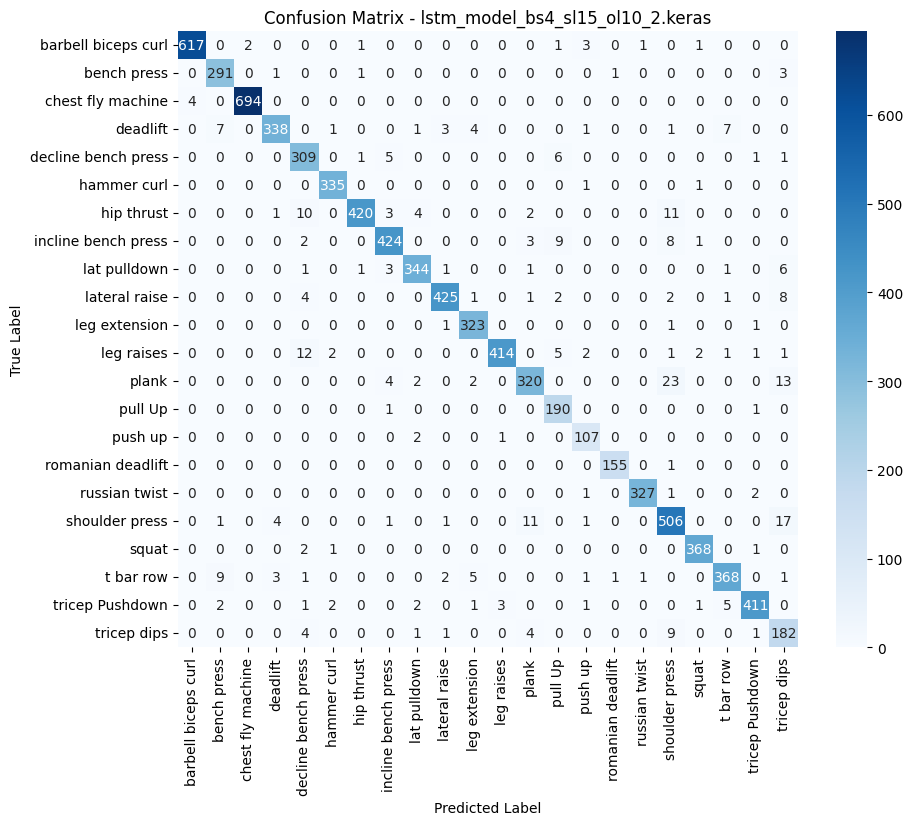

                     precision    recall  f1-score      support
barbell biceps curl   0.993559  0.985623  0.989575   626.000000
bench press           0.938710  0.979798  0.958814   297.000000
chest fly machine     0.997126  0.994269  0.995696   698.000000
deadlift              0.974063  0.931129  0.952113   363.000000
decline bench press   0.893064  0.956656  0.923767   323.000000
hammer curl           0.982405  0.994065  0.988201   337.000000
hip thrust            0.990566  0.931264  0.960000   451.000000
incline bench press   0.961451  0.948546  0.954955   447.000000
lat pulldown          0.966292  0.960894  0.963585   358.000000
lateral raise         0.979263  0.957207  0.968109   444.000000
leg extension         0.961310  0.990798  0.975831   326.000000
leg raises            0.990431  0.938776  0.963912   441.000000
plank                 0.935673  0.879121  0.906516   364.000000
pull Up               0.892019  0.989583  0.938272   192.000000
push up               0.906780  0.972727

In [ ]:
# Lưu kết quả
total_results = []

# Lặp qua từng model
for model_path in model_paths:
    # Trích xuất sequence length từ tên file model
    model_filename = os.path.basename(model_path)
    sequence_length = 30
    try:
        sequence_length = int(model_filename.split("_sl")[1].split("_")[0])
    except (IndexError, ValueError):
        print(f"Lỗi khi trích xuất sequence_length từ {model_filename}, lấy giá trị mặc định là 30!")

    print(f'Testing model: {model_path} with sequence length {sequence_length}')

    # Load dữ liệu với sequence length đã trích xuất
    X, y = load_data_with_fixed_length(data_path, sequence_length)

    # Scale dữ liệu
    scaler = MinMaxScaler()
    X = scaler.fit_transform(X.reshape(-1, 1)).reshape(X.shape)

    # Định nghĩa class_names nếu chưa có
    if 'class_names' not in locals():
        class_names = sorted([action for action in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, action))])

    # Xử lý NaN
    X = np.nan_to_num(X)

    # Load model
    model = tf.keras.models.load_model(model_path)

    # Đánh giá trên toàn bộ dữ liệu (100%)
    loss, accuracy = model.evaluate(X, y, verbose=0)
    print(f'Full Data Loss: {loss}, Full Data Accuracy: {accuracy}')

    # Dự đoán
    y_pred_prob = model.predict(X)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Vẽ Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_filename}')
    plt.show()

    # Báo cáo phân loại
    report = classification_report(y, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    print(report_df)

    # Lưu kết quả
    total_results.append({
        'Model': model_filename,
        'Sequence Length': sequence_length,
        'Full Data Loss': loss,
        'Full Data Accuracy': accuracy
    })

# Ghi kết quả vào file CSV
results_df = pd.DataFrame(total_results)
results_df.to_csv(output_file, index=False)
print(f'Results saved to {output_file}')